ggggg

# Quadcopter EKF - State Estimation for Figure-8 Trajectory Tracking

*An estimation-control companion to the Cascade-PID example.*

This notebook extends the <a href="https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html" target="_blank">Quadcopter Cascade-PID figure-8 example</a> so that the quadcopter no longer has access to its true state. Instead it carries an
**Extended Kalman Filter ($EKF$)** that reconstructs the full 12-state vector from
**noisy GPS and IMU measurements**, and the cascade controller closes the loop on
that *estimate*. The result is a complete, realistic **estimation-control pipeline**.

## Goal

Show how to build a framework-native $EKF$ in c4dynamics that:

- propagates the **same** nonlinear rigid-body dynamics used by the truth model
  during the *predict* stage, and
- corrects the estimate with **GPS** and **IMU** (gyroscope + accelerometer) plus a
  **magnetometer** during the *update* stage,

and to demonstrate, under realistic sensing (white noise + biases), how well the
vehicle tracks a figure-8 while flying on estimated state.

Because the $IMU$ here participates in *correction* rather than driving
*prediction* directly (Section 5.3 contrasts this with the strapdown-INS
architecture used by most real flight controllers), its update rate is a free
parameter with a measurable effect on tracking performance - not just a
demonstration of successful tracking at one fixed rate, but a concrete,
hands-on experiment (Section 8) in how measurement frequency shapes an
estimation-control loop.


## Overview

<div style="text-align: center;">
  <img src="architecture.png" alt="alt text">
  <figcaption> Figure 1: The EKF receives the same control inputs that drive the plant to predict the system state and incorporates GPS, IMU, and magnetometer measurements to correct the prediction. The resulting state estimate replaces the true state in the feedback loop, enabling output-feedback control based solely on sensor information.
   </figcaption>
</div>

### Notebook

1. Setup 
    imports the reusable modules 
2. The estimation problem | truth vs. estimate |
3. Dynamics | the shared dynamics |
4. Sensors | $GPS$, $IMU$, magnetometer - quantity measured, error model, measurement equation, and update role, for each |
5. The $EKF$ | the *predict* & *update* cycle, gating, adaptive noise, and how this compares to a strapdown INS |
6. Simulation | configuration and the single closed-loop run |
7. Results | true-vs-estimated states, ±2σ bands, NEES, RMSE |
8. GPS dropout experiment | dead-reckoning drift on $IMU$+magnetometer alone during a brief $GPS$ outage, across $IMU$ rates $20$–$200\,Hz$ |
9. Conclusions | what to expect, and where to take it next |

<a id="0"></a> <br>
 # Table of Contents  

1. [Setup](#1)
2. [The Estimation Problem](#2)
3. [Dynamics](#3)
4. [Sensors - The Measurements](#4)
5. [The Extended Kalman Filter](#5)
6. [Simulation](#6)
7. [Results](#7)
8. [GPS Dropout Experiment](#8)
9. [Conclusions & Possible Extensions](#9)


Everything reusable lives in the `c4dynamics`: 

The plant and cascade-$PID$ controller in `c4dynamics.controllers.quad_pid`, and the navigation sensors ($GPS$, $IMU$, magnetometer) in `c4dynamics.sensors.navigation` - both shared with the Cascade-$PID$ example. Only the estimator (the process/measurement Jacobians and the 12-state $EKF$) is specific to this example, in the companion file `ekf.py`.

This notebook only configures them and shows the results.

<a id="1"></a>
## 1. Setup

In [ ]:
import sys
# On Google Colab, install c4dynamics and fetch this example's own module (ekf.py):
if 'google.colab' in sys.modules:
    !pip install -q c4dynamics

import docs.source.programs.ekf_estimation.quad_ekf as quad_ekf                                                # this example's own EKF/estimator module
from c4dynamics.controllers.quad_pid import run_fig8_pid  # plant + cascade-PID controller (reused)


<a id="2"></a>
## 2. The Estimation Problem


New to Kalman filtering?
1. [c4dynamics's filters page](https://c4dynamics.github.io/c4dynamics/concepts/filters.html) provides a practical introduction to Kalman filtering, covering the underlying equations, the predict/update algorithm, and their implementation through the framework's kalman and ekf classes before applying them to realistic estimation problems.

2. [Kalman and Bayesian Filters in Python](https://rlabbe.github.io/Kalman-and-Bayesian-Filters-in-Python/) builds the intuition from scratch, in the same notebook-driven style as this example, before diving into the equations below.

---

In the Cascade-PID example the controller read the vehicle's **true** state directly.  
A real autopilot never sees truth, it only sees noisy sensors.  
The job of the $EKF$ is
to fuse those measurements with a dynamics model into a best estimate $\hat{x}$, which
the controller then uses in place of truth.

Two `state` objects run side by side on a single time loop:

- a **truth** `c4d.rigidbody`, propagated with the full nonlinear dynamics, and
- an **estimate** `ekf.ekf_quad` (a subclass of [c4d.filters.ekf](https://c4dynamics.github.io/c4dynamics/concepts/filters.html)),
updated from sensors.

They are coupled **only** through the sensors (truth → measurement → estimate) and
through control (estimate → controller → rotors → truth):

Because the framework $EKF$ is itself a `state` object, the estimate stores its own
history (`store`/`data`) and exposes named components (e.g. `est.phi`), so the controllers read it exactly as they read the truth rigidbody, no adapter is required.

The EKF algorithm operates as two sequential steps: Prediction (process model) --> Correction (measurement model).  
The structure of that notebook follows the same mental model as the algorithm.


\\ A VERY BRIEF INTRODUCTION TO EKF WITH REFERENCE TO THE FILTERS DOCS. 
EXPLAIN WHATS THE DIFF BETWEEN PREDICT AND CORRECT. WITH EMPHASIS ON WHAT WE ARE GOING TO DO FORWARD WHY WE NEED H AND h FOR EVERY SENSOR. 

<a id="3"></a>
## 3. Dynamics

The quadrotor dynamics is identical to this presented in the [parent example](https://c4dynamics.github.io/c4dynamics/programs/pid_cascade/quadcopter_pid.html).  
This section summarizes the governing equations, which form the process model
used by both the simulation and the Extended Kalman Filter ($EKF$).

The vehicle is the same 12-state quadcopter as the Cascade-PID example,
$$
\mathbf{x} =
\begin{bmatrix}
x & y & z &
v_x & v_y & v_z &
\varphi & \theta & \psi &
p & q & r
\end{bmatrix}^T
$$

Where
- $x, y, z$ are the inertial position coordinates of the quad [$m$]
- $v_x, v_y, v_z$ are the inertial velocity coordinates of the quad [$m/s$]
- $\varphi, \theta, \psi$ are three Euler angles representing roll, pitch, and yaw respectively [$rad$]
- $p, q, r$ are the body rates about $x,y,z$ respectively [$rad/s$]


The state evolves according to the nonlinear process model

$$
\dot{\mathbf x}=f(\mathbf x,\mathbf u),
$$

where the control input

$$
\mathbf u=
[\omega_1,\omega_2,\omega_3,\omega_4]^T
$$

consists of the four rotor speeds.

The translational motion consists of the position kinematics and Newton's second law:

$$
\dot{x} = v_x \\
\dot{y} = v_y \\
\dot{z} = v_z \\
\dot{v}_x = F_x\, /\ m \\
\dot{v}_y = F_y\, /\ m \\
\dot{v}_z = F_z\, /\ m
$$

The three force components form the inertial force vector $
\mathbf{F_i}=
\begin{bmatrix}
F_x&F_y&F_z
\end{bmatrix}^T \
[N]
$, and $m$ is the drone mass $[kg]$.

The body-frame forces are rotated into the inertial frame and combined with gravity $g$ in the negative $z$ direction:


$$
\mathbf F_i = [BI]^T \cdot \mathbf F_b
+ \begin{bmatrix}
0\\
0\\
-m \cdot g
\end{bmatrix}
$$

Where:
- $[BI]$ is the Body from Inertial $DCM$ (direction cosine matrix, generated by Euler angles in $3$-$2$-$1$ order).  
- $[BI]^T$ is the transpose of $[BI]$ and used to rotate vectors to the inertial frame from the body frame.  



<div style="text-align: center;">
  <img src="..\pid_cascade\quad_frame.png" alt="alt text">
  <figcaption> Figure 2: Reference systems. Inertial system: ENU (east, north, up). Body frame: (forward, right, down). Positive rotation about an axis is given by curling the right-hand fingers. Propellers rotation: 1: CCW (counter-clockwise) , 2: CCW, 3: CW, 4: CW.
   </figcaption>
</div>


Recall the convention for our examples:

Body frame:
- $x$ forward (between motors $1$ and $3$)
- $y$ right
- $z$ down

Inertial frame ($ENU$):
- $x$ east
- $y$ north
- $z$ up

Rotation:
$3$-$2$-$1$ = $ZYX$ = yaw $\rightarrow$ pitch $\rightarrow$ roll

The body-frame aerodynamic force is:

$$
\mathbf F_b
=
\begin{bmatrix}
-A_x \cdot u \\
-A_y \cdot v \\
T-A_z \cdot w
\end{bmatrix}
$$

where $Ax, Ay, Az$ are the aerodynamic drags in the $x,y,z$ body directions, and $u,v,w$ are the velocities of the drone in the body frame $v_b=\begin{bmatrix}u&v&w\end{bmatrix}^T$, and $T$ is the total thrust generated by the rotors.  

The body-frame velocity $v_b$ is obtained by rotating the inertial velocity by the rotation matrix that used to transform the vector force:

$$
\mathbf v_b = [BI] \cdot \mathbf v_i
$$


where $\mathbf v_i$ is the vector of inertial velocities: $\mathbf v_i=\begin{bmatrix}v_x&v_y&v_z\end{bmatrix}^T$.

The rotors produce the total thrust vector $T$, which generates translational force, and thrust moments, $\tau_x, \tau_y, \tau_z$, that generate rotational motion.

The rotational dynamics consist of Euler-angle kinematics and Euler's rigid-body rotational equations.  

The Euler-angle kinematics:

$$
\dot\varphi = p + (q \cdot \sin\varphi + r \cdot \cos\varphi) \cdot \tan\theta
$$

$$
\dot\theta = q \cdot \cos\varphi - r \cdot \sin\varphi
$$

$$
\dot\psi = \frac{q \cdot \sin\varphi + r \cdot \cos\varphi}{\cos\theta}
$$

Where $\varphi, \theta, \psi$ are three Euler angles (roll, pitch, yaw respectively [rad]) and $p, q, r$ are the body rates about $x,y,z$ respectively [rad/s].

And the body rates dynamics:

$$
\dot p = \frac{M_x-(I_{zz}-I_{yy}) \cdot q \cdot r}{I_{xx}}
$$

$$
\dot q = \frac{M_y-(I_{xx}-I_{zz}) \cdot p \cdot r}{I_{yy}}
$$

$$
\dot r = \frac{M_z-(I_{yy}-I_{xx}) \cdot p \cdot q}{I_{zz}}
$$

Where $I_{xx}, I_{yy}, I_{zz}$ are the quad moments of inertia about $x, y, z$ respectively.

The net moments $M_x, M_y, M_z$ consist of control torques, aerodynamic damping, and gyroscopic coupling:

$$
M_x = \tau_x - A_r \cdot p - I_R \cdot q \cdot \Omega
$$

$$
M_y = \tau_y - A_r \cdot q + I_R \cdot p \cdot \Omega
$$

$$
M_z = \tau_z - A_r \cdot r
$$

Where:
- $\tau_x, \tau_y, \tau_z$ are the roll, pitch, and yaw control torques generated by the motors.
- $A_r$ is the aerodynamic rotational drag coefficient. The terms $A_r \cdot p, A_r \cdot q, A_r \cdot r$ represent damping moments that oppose the corresponding angular rates.
- $I_R$ is the rotor moment of inertia, and $\Omega$ is the net rotor angular speed. The terms
$I_R \cdot q \cdot \Omega$ and ​$I_R \cdot p \cdot \Omega$ ​are gyroscopic coupling moments produced by the angular momentum of the spinning rotors. The gyroscopic terms couple the roll and pitch dynamics: a pitch rate generates a roll moment, and a roll rate generates a pitch moment.

The net rotor angular speed entering the gyroscopic coupling is

$$
\Omega = \omega_1+\omega_2-\omega_3-\omega_4
$$

And the thrust produced by each individual motor is given by:

$$
F_i = k_T \cdot \omega_i^2
$$

The total thrust is:

$$
T = F_1 + F_2 + F_3 + F_4
$$

And the control moments are:

$$
\tau_x
=
L \cdot (-F_1 + F_2 + F_3 - F_4)
$$

$$
\tau_y = L \cdot (F_1-F_2+F_3-F_4)
$$

$$
\tau_z = \frac{k_Q}{k_T} \cdot (F_1+F_2-F_3-F_4)
$$




The thrust and torque mappings assume the following $X$-configuration:

$X$ configuration:
- $\omega_1$: $CCW$   (+) front
- $\omega_2$: $CCW$   (+) rear  
- $\omega_3$: $CW$      (-) left  
- $\omega_4$: $CW$      (-) right

Torque mapping:
- roll ($\varphi$):       $L \cdot (-F1 + F2 + F3 - F4)$
- pitch ($\theta$):    $L \cdot (F1 - F2 + F3 - F4)$
- yaw ($\psi$):        ${kM \over kT} \cdot (F1 + F2 - F3 - F4)$


The simulation and the the $EKF$ use the same nonlinear process model.  
The difference is that the simulator propogates the true state, whereas the $EKF$ predicts the state from the previous estimate and corrects it using only noisy measurements from the $GPS$, $IMU$, and magnetometer.

Because the process model is non-linear, it cannot be represented by a single constant state-transition matrix.
Instead, the $EKF$ linearizes the dynamics about the current operating point at every prediction step.
This linearization is represented by the Jacobian of $f(\mathbf{x}, \mathbf{u})$.

The equations above completely define the $EKF$ prediction model.

The second stage of the $EKF$ incorporates measurements from the onboard sensors
to correct the predicted state. Before deriving the $EKF$ equations, we therefore
introduce the sensor models used in this example.

<a id="4"></a>
## 4. Sensors - The Measurements

Unlike the simulator, which has access to the true state, the $EKF$ receives
information only through noisy sensor measurements. This example models three
onboard sensors  $GPS$, $IMU$ (gyroscope + accelerometer), and a magnetometer
implemented in `c4dynamics.sensors.navigation` and shared with the Cascade-PID
example.

Each sensor maps the **true** state to a noisy, biased measurement, the only
path by which truth reaches the estimator and is described below by four
things: the physical quantity it measures, its error model (noise and bias,
as configured in Section 6), its measurement equation $h(\mathbf x)$, and how
it enters the $EKF$'s *update* stage. Section 5.2 covers the update mechanics
shared by every sensor innovation, gating, gain once; here we note only
what's sensor-specific.

The appendix demonstrates each sensor's actual simulated measurement against
its true state, visually.

### 4.1. $GPS$

**Measures** the inertial position $x,y,z$ directly.

**Error model.** White noise, $\sigma_{gps}=0.5\,m$ per axis ($1\sigma$), plus
an optional constant bias (off by default). Sampled at $10\,Hz$.

**Measurement equation.** Linear  $GPS$ reads out three of the twelve states
directly:

$$
h(\mathbf x) = H_{gps} \cdot \mathbf x, \qquad
H_{gps} =
\begin{bmatrix}
1&0&0&0&\cdots&0 \\
0&1&0&0&\cdots&0 \\
0&0&1&0&\cdots&0
\end{bmatrix}
$$

**Update.** A $3$-dimensional innovation, gated at the $\chi^2_3$ 95%
threshold (Section 5.2). $GPS$ is the *only* sensor with an adaptive $R$:
its assumed noise, $R_{gps}=\mathrm{diag}(0.5^2,0.5^2,0.5^2)$, is inflated
online (Mehra-style) whenever recent innovations run larger than expected
e.g. during a $GPS$-quality dip, so the filter automatically trusts it less
rather than being pulled off course.

### 4.2. $IMU$ - Gyroscope

**Measures** the body rates $p,q,r$ directly (a rate gyro).

**Error model.** White noise, $\sigma_{gyro}=0.01\,rad/s$ per axis, plus an
optional constant bias. Sampled at $200\,Hz$ by default, Section 8 explores
what happens at other rates.

**Measurement equation.** Linear, another direct read-out, this time of the
last three states:

$$
h(\mathbf x) = H_{gyro}\,\mathbf x, \qquad
H_{gyro}[i,\ 9{+}i] = 1 \;\; (i=0,1,2)
$$

**Update.** A $3$-dimensional innovation, gated at the $\chi^2_3$ threshold.
$R_{gyro}=\mathrm{diag}(0.015^2,0.015^2,0.015^2)$  set a little above the raw
noise variance ($0.01^2$) as a margin, since the gyro's own bias isn't
estimated in this example.

### 4.3. $IMU$ - Accelerometer

**Measures** specific force in the body $x,y,z$ axes. What an accelerometer
actually senses is gravity *and* the vehicle's own coordinate acceleration
combined, it has no way to tell them apart. That combination is exactly what
makes this sensor useful for more than attitude alone.

**Error model.** White noise, $\sigma_{acc}=0.05\,m/s^2$ per axis, plus an
optional constant bias.

**Measurement equation.** $h(\mathbf x)$ predicts the
body-frame specific force by calling the same `dynamics()` used as the
process model:

$$
h(\mathbf x) = \Big([BI]\cdot\big(\mathbf a_{\text{inertial}} +
\begin{bmatrix}0&0&g\end{bmatrix}^T\big)\Big)_{x,y}
$$

where $\mathbf a_{\text{inertial}}=\dot{\mathbf v}$ comes straight from
`dynamics()` (which already includes "g" in the negative direction, 
hence adding it back makes $[BI]$ act on pure specific force), and $[BI]$ is the same body-from-inertial
rotation used throughout Section 3.  

$H_{acc}=\partial h/\partial x$ is computed **numerically**, for the same
reason as `jacobian_F`'s translational block (Section 5.1): the DCM-coupled
model isn't practical to hand-differentiate reliably.

**Update.** A $2$-dimensional innovation, gated at the $\chi^2_2$ threshold.
$R_{acc}=\mathrm{diag}(0.10^2,0.10^2)$  around $\times4$ the raw noise
variance ($0.05^2$), a margin for the residual model error that remains even
with the full specific-force model (Euler discretization, the truth's own
finite-difference approximation of its own acceleration, etc.).

### 4.4. Magnetometer

**Measures** heading (yaw) $\psi$ directly.

**Error model.** White noise, $\sigma_{mag}=0.05\,rad$, plus an optional
constant bias. Sampled at $50\,Hz$.

**Measurement equation.** Linear, reading out a single state:

$$
h(\mathbf x) = \psi, \qquad
H_{mag} = \begin{bmatrix}0&\cdots&0&1&0&0&0\end{bmatrix}
$$

**Update.** A $1$-dimensional innovation, gated at the $\chi^2_1$ threshold.
$R_{mag}=0.055^2$. The one wrinkle: yaw is an angle, so the innovation is
wrapped to $[-\pi,\pi]$ before gating (Section 5.2), without this, an
estimate near $\pm\pi$ would be corrected the *wrong way round* the circle.

| Sensor | Observes | Rate | Model | $\sigma$ (1$\sigma$) |
|---|---|---|---|---|
| $GPS$ | position $x,y,z$ | $10\,Hz$ | linear | $0.5\,m$ |
| $IMU$ - gyro | body rates $p,q,r$ | $200\,Hz$ | linear | $0.01\,rad/s$ |
| $IMU$ - accel | specific force $a_x,a_y$ | $200\,Hz$ | **nonlinear** | $0.05\,m/s^2$ |
| Magnetometer | heading $\psi$ | $50\,Hz$ | linear (angle-wrapped) | $0.05\,rad$ |

<a id="5"></a>
## 5. The Extended Kalman Filter

The $EKF$ combines the two models introduced in the previous sections: the nonlinear quadrotor dynamics provide the process model for the prediction stage, while the $GPS$, $IMU$, and magnetometer define the measurement models used during the correction stage.

### 5.1. Process Model - The *Predict* Stage

The EKF's process model **is** the truth dynamics, $\dot{x}=f(x,u)$ - the very same
`c4dynamics.controllers.quad_pid.dynamics`. This "one model, two roles" is the heart
of the design: the truth integrates $f$ with `solve_ivp`, while the EKF integrates
the same $f$ with a single Euler step and propagates the covariance through its
Jacobian.

**State prediction (Euler):**
$$ \hat{x}_k^- = \hat{x}_{k-1}^+ + f(\hat{x}_{k-1}^+, u) \cdot \Delta t $$

**Covariance prediction (2nd-order discretization):**
$$
F = \left.\frac{\partial f}{\partial x}\right|_{\hat{x}}, \qquad
$$

The Jacobian $F$, `ekf.jacobian_F`, is a **hybrid**: the kinematics and Euler's
rotational-equations blocks (including the rotor gyroscopic coupling) are closed
form, since they depend only on body rates and inertia. The translational block
(drag + thrust-to-attitude coupling) is instead differentiated **numerically**
against `dynamics()` itself - the DCM/body-frame-drag model couples drag to
attitude in a way that isn't practical to hand-differentiate reliably, and computing
it numerically keeps the Jacobian correct automatically if the dynamics model ever
changes. The process noise $Q$ is increased on the velocity channel during
high-acceleration segments (adaptive $Q$).

In c4dynamics this maps directly onto `ekf.predict(F=F_d, fx=f, dt=dt, Q=Q)`.


### 5.2. Measurement Model - The *Update* Stage

Each one of the sensors that were presented in section 4 is represented by a measurement model:

$$
\mathbf z=h(\mathbf x) + \mathbf \nu
$$


where $h(\cdot)$ maps the system state to the sensor output and
$\mathbf \nu$ is the measurement noise.



For each sensor the EKF forms the innovation, tests it, and corrects:

$$ y = z - h(\hat{x}), \qquad S = H P H^\top + R, \qquad
   \text{NIS} = y^\top S^{-1} y. $$

**Innovation gating.** If $\text{NIS}$ exceeds the $\chi^2$ 95% threshold for that
sensor's dimension, the measurement is rejected as an outlier. Otherwise:

$$ K = P H^\top S^{-1}, \qquad
   \hat{x}^+ = \hat{x}^- + K y, \qquad
   P^+ = (I-KH)P^-. $$

Two refinements are applied as a thin layer over the framework `update`:

- **Adaptive GPS $R$** - when GPS innovations grow, $R_{\text{gps}}$ is inflated so the
  filter down-weights degraded measurements (a Mehra-style two-phase scheme).
- **Angle-wrapped yaw** - the magnetometer innovation is wrapped to $[-\pi,\pi]$ so a
  yaw estimate near $\pm\pi$ is corrected toward the measurement, not away from it.

All of this is encapsulated in `ekf.ekf_quad`; the controllers and the loop never see it.

### 5.3. A Note on Architecture: This EKF vs. a Strapdown INS

It's worth being explicit about a design choice, since it differs from what
most real flight controllers do. In this notebook the **predict** stage uses
the full nonlinear quadrotor dynamics together with the *commanded* rotor
speeds (Section 5.1) the same model driving the truth vehicle and **all**
of $GPS$, $IMU$, and magnetometer are fused during **correction** (Section
5.2, Section 4).

Production autopilots (e.g. PX4, ArduPilot) typically use a different split,
a **strapdown inertial navigation system (INS)**:

- The **gyroscope and accelerometer drive prediction directly**, their
  readings are integrated forward (attitude from the gyro; velocity and
  position from the accelerometer, once rotated into the inertial frame and
  corrected for gravity) at a high rate, with no dynamics model and no
  knowledge of the commanded inputs involved at all.
- $GPS$, magnetometer, and other aiding sensors are used **only during
  correction**, to bound the drift that inevitably accumulates from
  integrating noisy, biased IMU signals open-loop.

Why the difference? A strapdown INS doesn't need a dynamics model or the
commanded inputs at predict time, it can run on any vehicle, since it only
integrates what the IMU physically measures. That generality costs accuracy
between corrections: double-integrating a noisy, biased accelerometer for
position accumulates error quickly (the well-known INS drift problem), while
this example's dynamics-driven predict step is constrained by the actual
physics of *this specific* vehicle and stays close to truth even during a
$GPS$ gap. The trade-off is that this approach needs and only works with
an accurate model of the vehicle it's estimating, whereas a strapdown INS is
essentially vehicle-agnostic, which is why it remains the standard
architecture across aircraft, ships, and spacecraft as well as multirotors.

The two aren't mutually exclusive in practice, many real systems run a
strapdown INS *and* a model-based predictor together, or switch between them
depending on flight phase. Section 8 gives a concrete, hands-on illustration
of one consequence of *this* notebook's architecture: because the IMU here
participates in *correction* rather than driving prediction directly, its
update **rate** is a tunable knob with a measurable effect on tracking
performance, which we explore next.

<a id="6"></a>
## 6. Simulation

The estimation block - process noise $Q$, measurement noise $R$, initial covariance
$P_0$, the initial-estimate offset, the injected sensor noise, and the sensor rates
is provided as data, the estimation analogue of the controller-gain block. Start from
the reference block and tune as needed.

In [ ]:
ekf_cfg = quad_ekf.default_ekf_config()    # reference EKF noise / init block

Sections 5.1-5.2 described $Q$, $P_0$ and $R$ conceptually; here are the actual
values, exactly as returned by `default_ekf_config()`, shown as $1\sigma$
(the diagonal's square root) so they're comparable to the sensor $\sigma$'s in
Section 4's table. `ekf_cfg` is a plain dict - copy it, edit any entry, and pass
it to `run_fig8_ekf`/`run_gps_dropout_sweep` to experiment.

In [24]:
import numpy as np

def _sigma(M):
    return np.sqrt(np.diag(np.atleast_2d(M)))

labels = ('x','y','z','vx','vy','vz','phi','theta','psi','p','q','r')
print(f"{'state':<8}{'Q sigma (process)':<20}{'P0 sigma (init)':<18}")
for lbl, qs, ps in zip(labels, _sigma(ekf_cfg['Q']), _sigma(ekf_cfg['P0'])):
    print(f'{lbl:<8}{qs:<20.4f}{ps:<18.4f}')

print()
print(f"{'sensor':<12}{'R sigma (measurement)':<22}")
print(f"{'gps':<12}{_sigma(ekf_cfg['R_gps'])[0]:<22.4f}")
print(f"{'gyro':<12}{_sigma(ekf_cfg['R_gyro'])[0]:<22.4f}")
print(f"{'mag':<12}{_sigma(ekf_cfg['R_mag'])[0]:<22.4f}")
print(f"{'accel':<12}{_sigma(ekf_cfg['R_acc'])[0]:<22.4f}")

state   Q sigma (process)   P0 sigma (init)   
x       0.0050              0.5000            
y       0.0050              0.5000            
z       0.0080              0.8000            
vx      0.0200              0.5000            
vy      0.0200              0.5000            
vz      0.0250              0.6000            
phi     0.0080              0.0500            
theta   0.0080              0.0500            
psi     0.0100              0.0500            
p       0.0120              0.1000            
q       0.0120              0.1000            
r       0.0120              0.1000            

sensor      R sigma (measurement) 
gps         0.5000                
gyro        0.0150                
mag         0.0550                
accel       0.1000                


In [25]:
filter = {
    'R'         : 0,
    'gps_gate'  : 0,
}

In [26]:
quadcopter = {
    'm'  : 0.468,        # mass [kg]
    'g'  : 9.81,         # gravity [m/s^2]
    'l'  : 0.225,        # arm length - center to motor [m]
    'kT' : 2.98e-6,      # thrust coefficient  [N/(rad/s)^2]
    'kQ' : 0.0382,       # torque coefficient  [N.m/(rad/s)^2]
    'Ixx': 4.856e-3,     # roll  inertia [kg.m^2]
    'Iyy': 4.856e-3,     # pitch inertia [kg.m^2]
    'Izz': 8.801e-3,     # yaw   inertia [kg.m^2]
    'Ax' : 0.30,         # aero drag - x
    'Ay' : 0.30,         # aero drag - y
    'Az' : 0.25,         # aero drag - z
    'Ar' : 0.20,         # rotational drag - angular rates
    'IR' : 3.357e-5,     # rotor inertia [kg.m^2]
}

trajectory = {
    'A': 4.0,            # figure-8 X amplitude [m]
    'B': 2.0,            # figure-8 Y amplitude [m]
    'omega': 0.1,        # angular frequency [rad/s]  (period ~ 62.8 s)
    'z_ref': 1.5,        # hover altitude [m]
    't_end': 90.0,       # total simulation time [s]
}

controller = {

    # Inner loop - angular rate (200 Hz)
    'Kp_p': 0.80, 'Ki_p': 0.0001, 'Kd_p': 0.010,
    'Kp_q': 0.80, 'Ki_q': 0.0001, 'Kd_q': 0.010,
    'Kp_r': 0.60, 'Ki_r': 0.0001, 'Kd_r': 0.008,

    # Middle loop - attitude (100 Hz)
    'Kp_phi': 6.0, 'Ki_phi': 0.0001, 'Kd_phi': 0.80,            'AW_phi'  : 0.5,
    'Kp_theta': 6.0, 'Ki_theta': 0.0001, 'Kd_theta': 0.80,      'AW_theta': 0.5,
    'Kp_psi': 4.0, 'Ki_psi': 0.5, 'Kd_psi': 0.40,               'AW_psi'  : 0.5,

    # Outer loop - position (50 Hz)
    'Kp_x': 0.80, 'Ki_x': 0.00, 'Kd_x': 0.50,                   'AW_x'    : 0.5,
    'Kp_y': 1.00, 'Ki_y': 0.00, 'Kd_y': 0.70,                   'AW_y'    : 0.5,
    'Kp_z': 8.0, 'Ki_z': 8.0, 'Kd_z': 1.50,                     'AW_z'    : 3.0,

    # Velocity feedforward
    'Kff_x': 0.35, 'Kff_y': 0.40,

    # Limits
    'N_rate'            : 50,         # Filter coefficient for derivative term in rate controller
    'omega_max'         : 1000.0,     # max rotor speed [rad/s]
    'T_max_factor'      : 4,          # max thrust factor: T_max = T_max_factor * K_thrust * omega_max**2 [N]
    'T_min'             : 0.0,        # min thrust [N]
    'att_cmd_limit'     : 0.314,      # Max attitude command [rad] = 18deg
    'yaw_rate_limit'    : 1.0,        # Max yaw rate command [rad/s]
}

simulation = {
    'dt': 0.005,    # master timestep [s] = inner loop (200 Hz)
    'tf': 90.0      # simulation end time [s]
}

In [27]:
# plug all the config files for the simulation entry:
config = {
    'quad'      : quadcopter,
    'trajectory': trajectory,
    'controller': controller,
    'sim'       : simulation,
}


In [ ]:
# One closed loop: truth flies on the EKF estimate; the EKF runs on GPS/IMU.
truth, est, diag = quad_ekf.run_fig8_ekf(config, ekf_cfg)

EKF closed-loop  |  tf = 90.0 s  |  control dt = 0.005 s  |  IMU = 200 Hz  (sim dt = 0.005 s)
EKF closed-loop complete.


<a id="7"></a>
## 7. Results

### What to expect

- **Position** ($x,y,z$): tracked to a few tens of centimetres - GPS at 10 Hz bounds
  the position error while the dynamics bridges the gaps between fixes.
- **Velocity** ($v_x,v_y,v_z$): thanks to the full specific-force accelerometer model
  (Section 5), horizontal velocity is typically estimated to a few centimetres/second
  even though there is no direct velocity sensor.
- **Attitude** ($\phi,\theta,\psi$): roll/pitch are observed by the accelerometer at
  200 Hz and stay within a couple of degrees; yaw relies on the 50 Hz magnetometer.
- **±2σ bands** should contain the truth most of the time, a sign the covariance is
  neither over- nor under-confident.
- **NEES** (normalised estimation error squared) is *ideally* around $n=12$; with the
  accelerometer's dynamic term now properly modeled (rather than absorbed as noise),
  don't be surprised to see it run somewhat below 12 - that means the filter is a
  little conservative (it reports more uncertainty than it turns out to need), which
  is a safer direction to be in than the reverse.


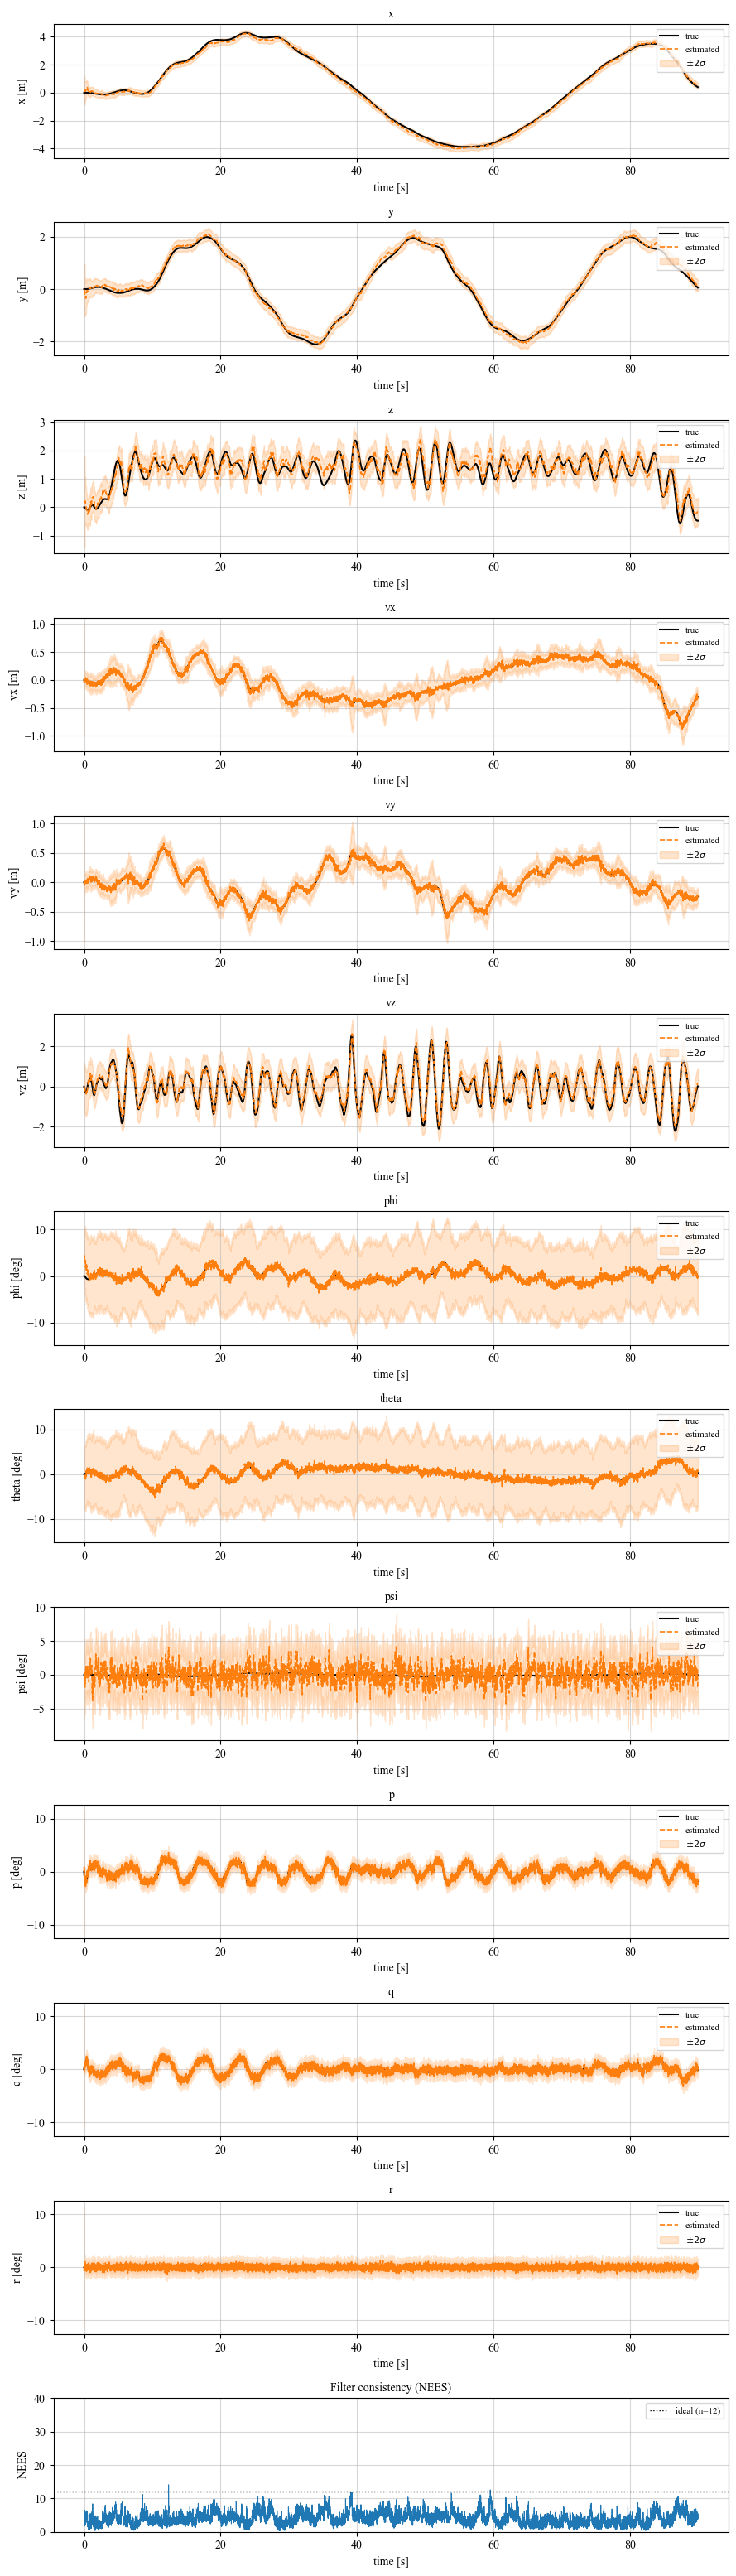

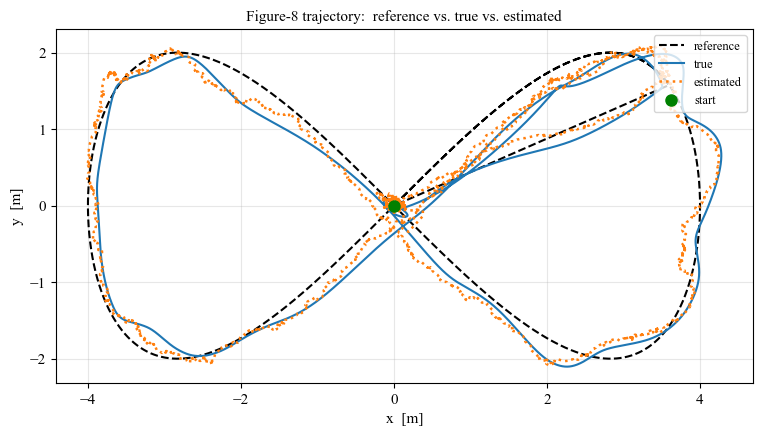

In [ ]:
fig = quad_ekf.plot_estimation(truth, est, diag, states=('x','y','z','vx','vy','vz','phi','theta','psi','p','q','r'))
fig8 = quad_ekf.plot_trajectory(truth, est, config)

### Tracking metrics

Per-state RMSE between truth and estimate over the figure-8 phase, plus the mean
NEES. NEES near 12 indicates the reported covariance is statistically honest.

In [ ]:
metrics = quad_ekf.compute_metrics(truth, est, diag)

state           RMSE
--------------------
x             0.1095
y             0.0780
z             0.1905
vx            0.0250
vy            0.0260
vz            0.1406
phi           0.0075
theta         0.0073
psi           0.0216
p             0.0055
q             0.0054
r             0.0057
--------------------
NEES            3.87   (ideal ~ 12)


<a id="8"></a>
## 8. GPS Dropout Experiment

Section 5.3 raised the real question: this notebook's EKF is always aided by
$GPS$, so what happens to IMU rate's importance if that aiding disappears?
That's the strapdown-INS regime - the estimate has to dead-reckon on $IMU$
(and magnetometer, for heading) alone.

This section disables $GPS$ for a short window mid-flight, $magnetometer$ and
$IMU$ keep updating as usual and measures how much the position estimate
drifts from truth during that window, across several $IMU$ rates.

**Why the window is short (~1.5 s), and not longer.** This $EKF$ is a
first-order (not iterated/unscented) filter: its correction is a
linearization around the *current* estimate, valid when that estimate is
close to truth. Early testing of this section found that with a *long*
$GPS$-denied window (several seconds), the estimate can drift far enough that
each further correction is computed from an increasingly wrong linearization
point, a known $EKF$ weakness and at that point *more* corrections can
make things *worse*, not better, which demonstrates a different (and
separate) phenomenon than the one this section is about. Keeping the window
short enough that linearization stays valid isolates the intended effect.

**Same controls as Section 7's rate sweep**: the control loop stays at a
fixed $200\,Hz$ regardless of IMU rate, and the accelerometer/gyro noise is
rescaled with rate so a faster IMU isn't an unrealistic free precision win
(see `run_fig8_ekf`'s docstring). `jacobian_stride=4` keeps this section fast
under two minutes for the sweep below.

In [31]:
# Same vehicle & gains as Section 6, a shorter flight so the sweep is fast,
# and GPS disabled for 1.5 s once the figure-8 is well underway.
trajectory_dropout = dict(trajectory, t_takeoff=1.5, t_land=1.5)
simulation_dropout = {'dt': 0.005, 'tf': 10.0}
config_dropout = {
    'quad'      : quadcopter,
    'trajectory': trajectory_dropout,
    'controller': controller,
    'sim'       : simulation_dropout,
}
DROPOUT_WINDOW = (3.0, 4.5)   # 1.5 s, GPS off; IMU + magnetometer stay on

ekf_cfg.update(
  ideal_imu = True,
  ideal_magnetometer = True,
  R_gyro = np.eye(3) * 1e-3,
  R_mag = np.eye(1) * 1e-3,
  R_acc = np.eye(2) * 1e-3,
)

# dropout_sweep = ekf.run_gps_dropout_sweep(
#     config_dropout, ekf_cfg,
#     imu_rates_hz=(20, 50, 100, 200, 400, 1000, 2000),
#     dropout_window=DROPOUT_WINDOW,
#     n_trials=20,
#     jacobian_stride=4,
# )

dropout_sweep = quad_ekf.run_gps_dropout_sweep(
    config_dropout, ekf_cfg,
    imu_rates_hz=(100),
    dropout_window=DROPOUT_WINDOW,
    n_trials=20,
    jacobian_stride=4,
    seeds = [5]
)

TypeError: 'int' object is not iterable

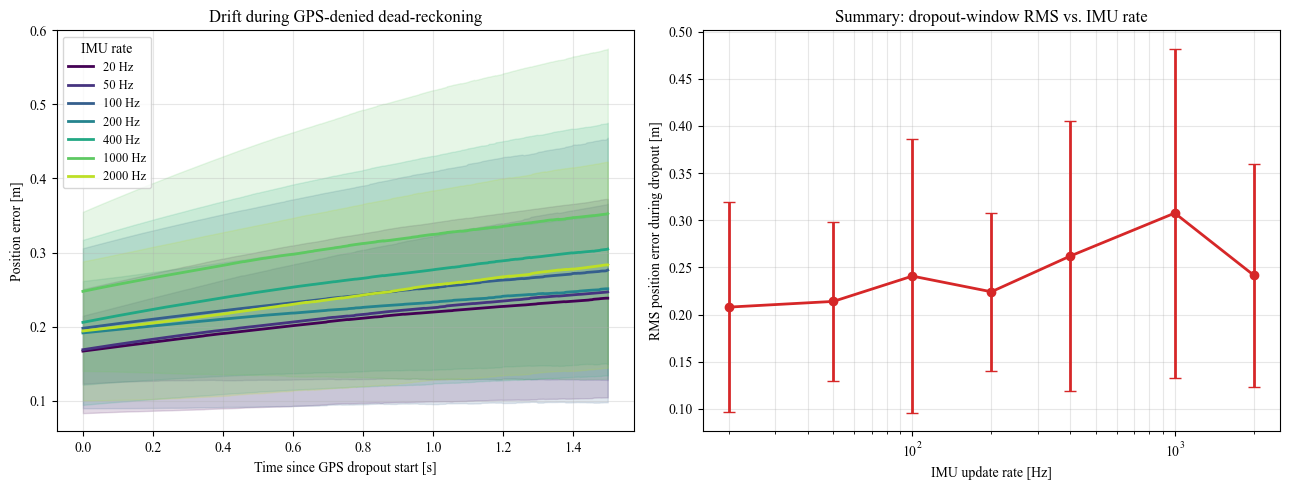

In [ ]:
fig = quad_ekf.plot_gps_dropout(dropout_sweep)

**Reading this honestly.** The left panel's drift curves are the real,
reliable result: every rate shows position error genuinely *growing* over
the 1.5 s window as the estimate dead-reckons without $GPS$, the mechanism
this section set out to demonstrate works. That's the core, dependable
takeaway: **losing the absolute position reference makes the estimate drift,
visibly and measurably, in a way the always-aided Section 6-7 setup never
shows.**

The rate-dependence itself (right panel) is real but noisy at this trial
count, the shaded bands and error bars overlap substantially, and the point
estimates don't yet trace a clean, confident "faster IMU drifts less" curve.
Bump `n_trials` up (10+) if you want tighter error bars and a clearer verdict
on the ordering; the trend so far is suggestive rather than conclusive. This
is worth sitting with rather than papering over: it's a genuine result about
how much trial-to-trial noise this particular experiment has, at this
duration, in this closed loop not a bug to be tuned away.

**Why the sweep stops at 200 Hz.** Rates were also tested well beyond 200 Hz (up to 1000 Hz); performance kept getting worse, not better. A follow-up check identified the specific cause: disabling only the accelerometer correction during the dropout window, while leaving the gyroscope and magnetometer active, reverses the trend, RMS error then improves with rate instead of worsening. The accelerometer is this filter's one genuinely nonlinear measurement (Section 5.1), and each correction linearizes around the current state estimate; once GPS is gone long enough for that estimate to drift, further accelerometer corrections are computed around an increasingly wrong linearization point, and correcting more often reinforces that error rather than reducing it. The gyroscope and magnetometer, whose measurement models do not share this nonlinearity, show no such effect on their own. Rather than chase a fix here, the reported sweep is capped at 200 Hz with this note: **beyond 200 Hz, this EKF's accuracy does not improve and gets worse, for a specific and now-identified reason.**

<a id="9"></a>
## 9. Conclusions & Possible Extensions

The same figure-8 that the Cascade-PID example flew on perfect state is now flown on a
state **estimated** from noisy GPS and IMU, a complete estimation-control pipeline,
built entirely on c4dynamics abstractions (`c4d.rigidbody`, `c4d.filters.ekf`, the
sensor pattern, and `store`/`data`).

Section 8 added a second thread: because this architecture fuses the IMU
during correction rather than using it to drive prediction directly (Section
5.3), the IMU's update rate is a concrete, measurable knob on performance
exactly the kind of question a strapdown-INS architecture would answer
differently, since there the IMU rate *is* the prediction rate.

Natural next steps:

- **Sensor biases & bias estimation** : turn on the constant biases in the sensors and
  augment the state to estimate them online.
- **GPS velocity** : add a lower-rate velocity measurement to tighten the velocity
  channel.
- **Waypoint / trajectory generation** : replace the analytic figure-8 with a planner.
- **Degraded sensing** : stress the filter with GPS dropouts or inflated noise and
  watch the adaptive $R$ and innovation gate respond.

# Appendix: Sensor Model Demonstrations

## Demos

In [ ]:
from c4dynamics.sensors.navigation import imu, gps, magnetometer


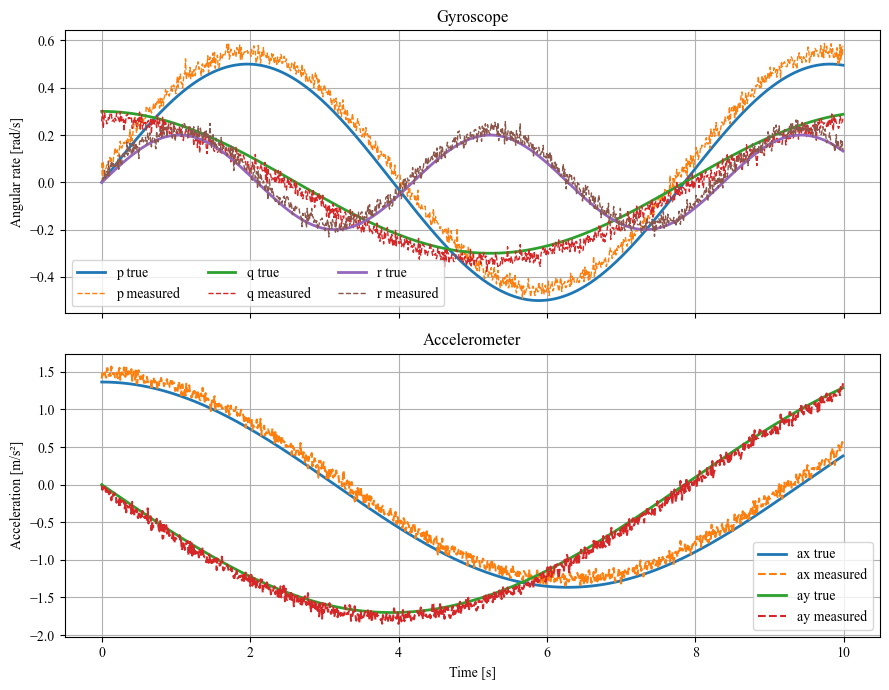

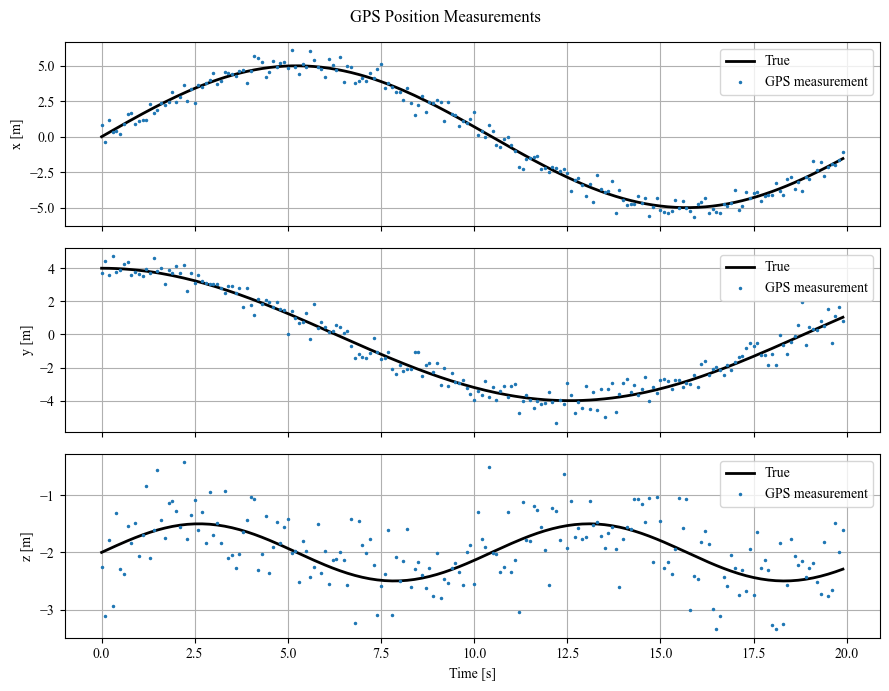

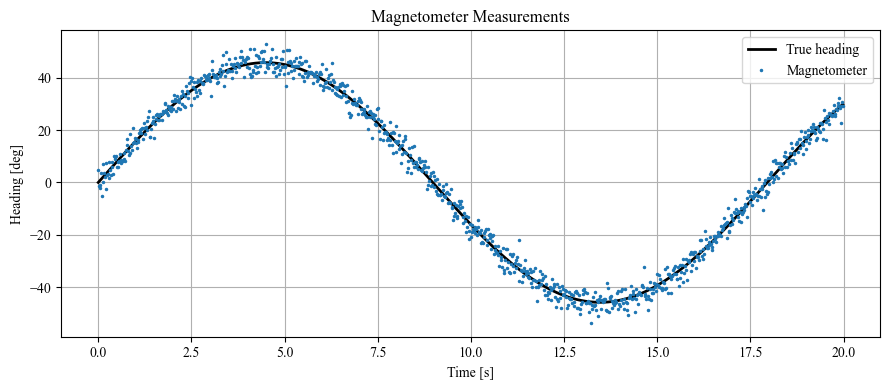

In [ ]:
imu.demo();
gps.demo();
magnetometer.demo();